<a href="https://colab.research.google.com/github/Ajayyadav1586/Book_recommender_system/blob/main/spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv('spam1.csv', encoding='latin1')

In [3]:
df.shape

(5572, 5)

In [4]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.tail()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


In [6]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
813,ham,I borrow ur bag ok.,NaN,NaN,NaN
4264,ham,&lt;DECIMAL&gt; m but its not a common car he...,NaN,NaN,NaN
1401,ham,Kaiez... Enjoy ur tuition... Gee... Thk e seco...,NaN,NaN,NaN
1984,spam,Urgent! Please call 09061743810 from landline....,NaN,NaN,NaN
4755,ham,Don't make life too stressfull.. Always find t...,NaN,NaN,NaN


In [7]:
df.rename(columns = {"v1":"spam/ham","v2":"message"})
#for change columns name according to conviniance

,spam/ham,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [8]:
df.duplicated().sum()

np.int64(403)

In [9]:
df = df.drop_duplicates()

In [10]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [11]:
# df = df.dropna()
# df['v1'] = df['v1'].map({'ham': 0, 'spam': 1})


In [12]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [13]:
df.head(20)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [14]:
df = df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"])

In [15]:
df = df.rename(columns={"v1": "spam/ham", "v2": "message"})
df["true/false"] = df["spam/ham"].map({"ham":0,"spam":1})

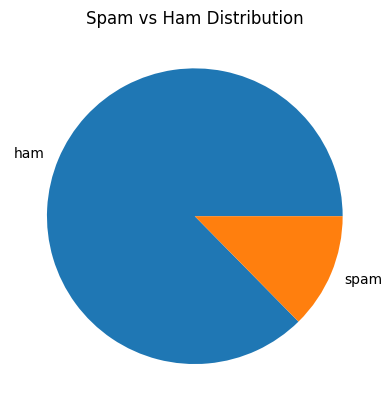

In [16]:
# EDA - Exploratory data analysis
# graph
# pie

import matplotlib.pyplot as plt


counts = df["spam/ham"].value_counts()
plt.title("Spam vs Ham Distribution")
labels = ["Ham", "Spam"]
peidata=plt.pie(counts, labels=counts.index)

plt.show()




In [17]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [18]:
df['count_character'] = df['message'].apply(len)

In [19]:
df["word_counts"]=df['message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [20]:
df["num_sentence"] = df['message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [21]:
print(df["true/false"].value_counts())

true/false
0    4516
1     653
Name: count, dtype: int64


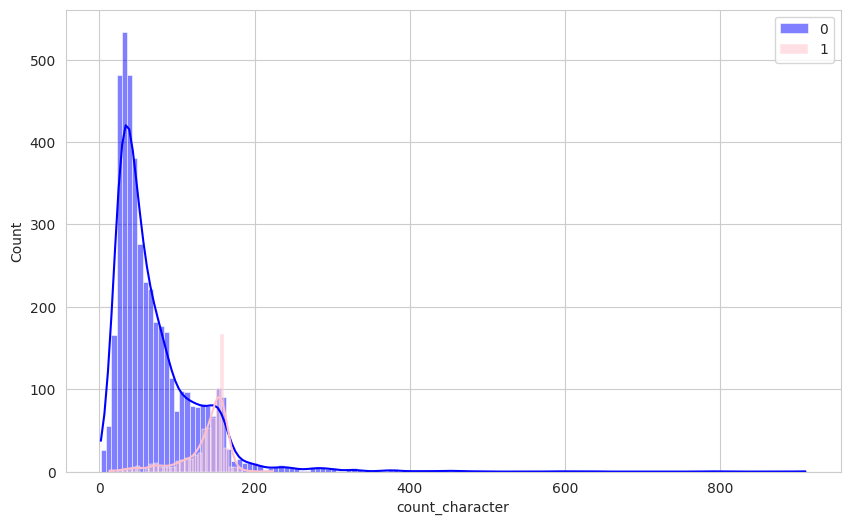

In [22]:
# import seaborn as sns
# sns.set_style("whitegrid")
# plt.figure(figsize=(10,6))
# sns.histplot(df(df["true/false" == 0]["count_character"]))
# sns.histplot(df(df["true/false" == 1]["count_character"]),color="pink")

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df[df["true/false"] == 0]["count_character"], color="blue", label="0", kde=True, alpha=0.5)
sns.histplot(df[df["true/false"] == 1]["count_character"], color="pink", label="1", kde=True, alpha=0.5)

plt.legend()
plt.show()


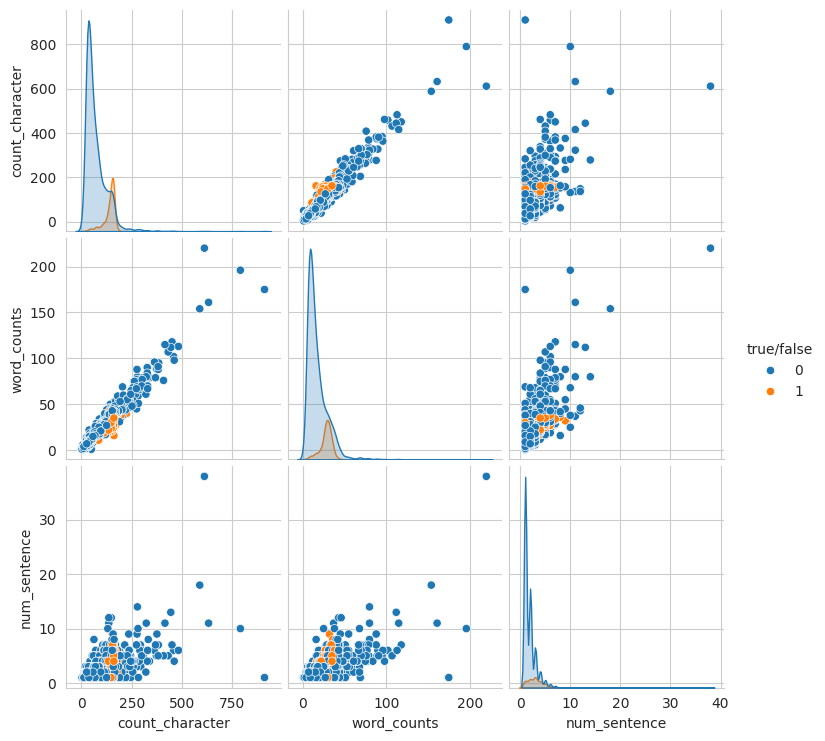

In [23]:
sns.pairplot(df,hue="true/false")

<Axes: >

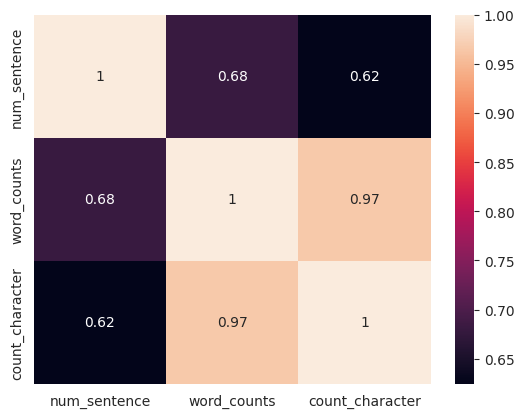

In [24]:
sns.heatmap(df[["num_sentence","word_counts","count_character"]].corr(),annot=True)

In [25]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords') # Ensure stopwords are downloaded

# data preprocessing
# lower case
# Tokenization
# Remove special char (non-alphanumeric)
# Remove stopwords
# Stemming

ps = PorterStemmer()

def data_preprocessing(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
      if i.isalnum(): # Corrected from isalum()
        y.append(i)

    text = y[:] # Update text with alphanumeric words
    y.clear()

    for i in text:
      if i not in stopwords.words('english') and i not in string.punctuation:
        y.append(i)

    text = y[:] # Update text with non-stopwords and non-punctuation
    y.clear()

    for i in text:
      y.append(ps.stem(i))

    return " ".join(y) # Keep only this return statement

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [26]:
df['data_preprocessing'] = df['message'].apply(data_preprocessing)

In [27]:
text = 'hey how have you been'
data_preprocessing(text)

'hey'

In [28]:
df['message'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [29]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [30]:
df['message'].apply(data_preprocessing)

,message
0,go jurong point crazi avail bugi n great world...
1,ok lar joke wif u oni
2,free entri 2 wkli comp win fa cup final tkt 21...
3,u dun say earli hor u c alreadi say
4,nah think goe usf live around though
...,...
5567,2nd time tri 2 contact u pound prize 2 claim e...
5568,b go esplanad fr home
5569,piti mood suggest
5570,guy bitch act like interest buy someth els nex...


In [31]:
df.head()

,spam/ham,message,true/false,count_character,word_counts,num_sentence,data_preprocessing
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,24,2,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,0,29,8,2,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,0,49,13,1,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,15,1,nah think goe usf live around though


In [32]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

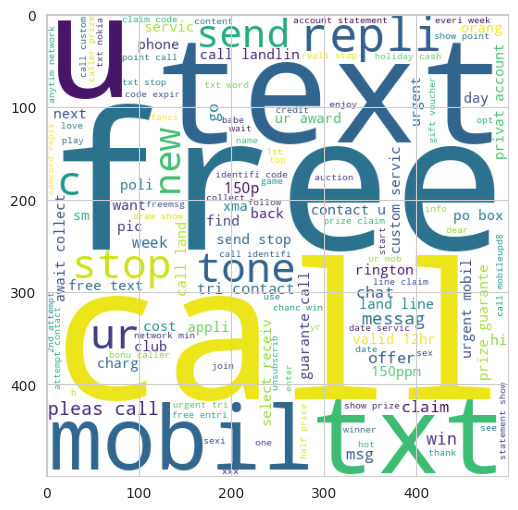

In [33]:
spam_messages_processed = df[df['true/false'] == 1]['data_preprocessing'].dropna().apply(lambda x: x if x.strip() else None).dropna()
if not spam_messages_processed.empty:
    spam_wc = wc.generate(" ".join(spam_messages_processed.tolist()))
    plt.figure(figsize=(15,6))
    plt.imshow(spam_wc)
else:
    print("No valid words found to generate spam word cloud after preprocessing.")

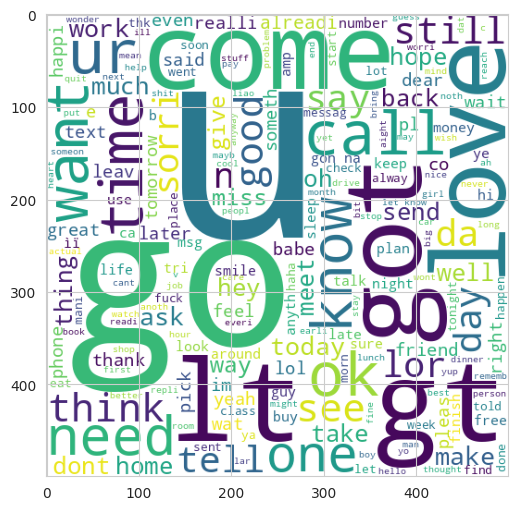

In [34]:
ham_messages_processed = df[df['true/false'] == 0]['data_preprocessing'].dropna().apply(lambda x: x if x.strip() else None).dropna()
if not ham_messages_processed.empty:
    ham_wc = wc.generate(" ".join(ham_messages_processed.tolist()))
    plt.figure(figsize=(15,6))
    plt.imshow(ham_wc)
else:
    print("No valid words found to generate ham word cloud after preprocessing.")

In [35]:
df.head()

,spam/ham,message,true/false,count_character,word_counts,num_sentence,data_preprocessing
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,24,2,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,0,29,8,2,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,0,49,13,1,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,15,1,nah think goe usf live around though


In [36]:
spam_corpus = []
for msg in df[df['true/false'] == 1]['data_preprocessing'].tolist():
  if msg: # Ensure msg is not empty
    for word in msg.split():
      spam_corpus.append(word)

In [37]:
len(spam_corpus)

9939

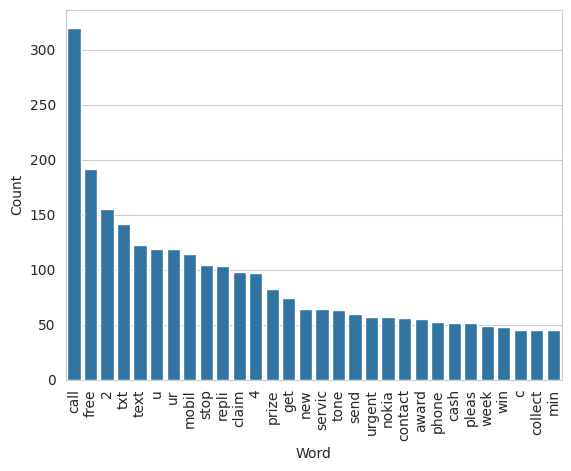

In [38]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for the most common spam words
spam_words_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['Word', 'Count'])

# Plot the barplot using the DataFrame
sns.barplot(x='Word', y='Count', data=spam_words_df)
plt.xticks(rotation='vertical')
plt.show()

In [39]:
ham_corpus = []
for msg in df[df['true/false'] == 0]['data_preprocessing'].tolist():
  if msg: # Ensure msg is not empty
    for word in msg.split():
      ham_corpus.append(word)

In [40]:
# --- Temporary Debug Cell: Inspecting Processed Spam/Ham Messages ---
print("--- Debugging Spam Messages ---")
spam_preprocessed_series = df[df['true/false'] == 1]['data_preprocessing']
print(f"Number of spam messages: {len(spam_preprocessed_series)}")
print(f"Number of non-empty processed spam messages: {sum(spam_preprocessed_series != '')}")
if not spam_preprocessed_series.empty:
    print(f"Sample of processed spam messages (head):\n{spam_preprocessed_series.head(5)}")
else:
    print("No spam messages found in 'data_preprocessing' column.")

print("\n--- Debugging Ham Messages ---")
ham_preprocessed_series = df[df['true/false'] == 0]['data_preprocessing']
print(f"Number of ham messages: {len(ham_preprocessed_series)}")
print(f"Number of non-empty processed ham messages: {sum(ham_preprocessed_series != '')}")
if not ham_preprocessed_series.empty:
    print(f"Sample of processed ham messages (head):\n{ham_preprocessed_series.head(5)}")
else:
    print("No ham messages found in 'data_preprocessing' column.")
# ---------------------------------------------------------------------

--- Debugging Spam Messages ---
Number of spam messages: 653
Number of non-empty processed spam messages: 653
Sample of processed spam messages (head):
2     free entri 2 wkli comp win fa cup final tkt 21...
5     freemsg hey darl 3 week word back like fun sti...
8     winner valu network custom select receivea pri...
9     mobil 11 month u r entitl updat latest colour ...
11    six chanc win cash 100 pound txt csh11 send co...
Name: data_preprocessing, dtype: object

--- Debugging Ham Messages ---
Number of ham messages: 4516
Number of non-empty processed ham messages: 4507
Sample of processed ham messages (head):
0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
3                  u dun say earli hor u c alreadi say
4                 nah think goe usf live around though
6        even brother like speak treat like aid patent
Name: data_preprocessing, dtype: object


In [41]:
len(ham_corpus)

35404

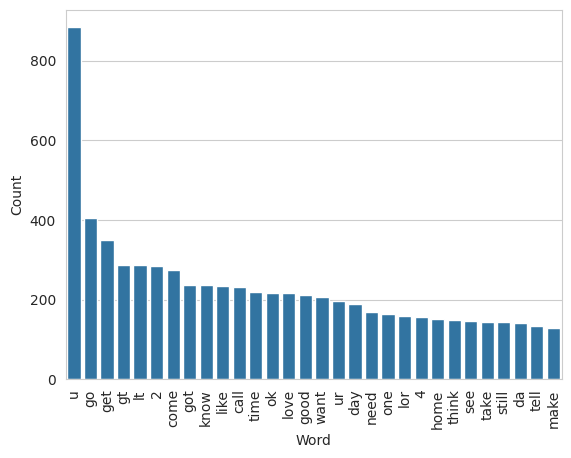

In [42]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for the most common ham words
ham_words_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['Word', 'Count'])

# Plot the barplot using the DataFrame
sns.barplot(x='Word', y='Count', data=ham_words_df)
plt.xticks(rotation='vertical')
plt.show()

In [43]:
# model building

In [44]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [45]:
X = cv.fit_transform(df['data_preprocessing']).toarray()

In [46]:
X.shape

(5169, 6708)

In [47]:
y = df['spam/ham'].values

In [48]:
y

array(['ham', 'ham', 'spam', ..., 'ham', 'ham', 'ham'], dtype=object)

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=2)

In [51]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [52]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [53]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1, pos_label='spam'))

0.8800773694390716
[[792 104]
 [ 20 118]]
0.5315315315315315


In [54]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2, pos_label='spam'))

0.9642166344294004
[[871  25]
 [ 12 126]]
0.8344370860927153


In [55]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3, pos_label='spam'))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [56]:
# tfidf --> MNB

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [58]:
svc = SVC(kernel='sigmoid',gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear',penalty='l1')
rfc = RandomForestClassifier(max_depth=5)
abc = AdaBoostClassifier(n_estimators=50)
bc = BaggingClassifier(n_estimators=50)
etc = ExtraTreesClassifier(n_estimators=50,max_depth=5)
gbdt = GradientBoostingClassifier(n_estimators=50,max_depth=5)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [59]:
clfs = {
    'SvC' : svc,
    'KN' : knc,
    'NB' : mnb,
    'DT' : dtc,
    'LR' : lrc,
    'RF' : rfc,
    'AdaBoost' : abc,
    'BgC' : bc,
    'ET' : etc,
    'GBDT' : gbdt,
    'xgb' : xgb
}

In [60]:
def data_preprocessing(clf,X_train,y_train,X_test,y_test):
  clf.fit(X_train,y_train)
  y_pred = clf.predict(X_test)
  current_accuracy = accuracy_score(y_test,y_pred)
  current_precision = precision_score(y_test,y_pred, pos_label='spam')
  return current_accuracy, current_precision

In [61]:
data_preprocessing(svc,X_train,y_train,X_test,y_test)

(0.9264990328820116, 0.7421875)

In [62]:
accuracy_source = []
precision_source = []
algorithm_names = []

for name,clf in clfs.items():
  try:
    current_accuracy,current_precision = data_preprocessing(clf,X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    print()

    accuracy_source.append(current_accuracy)
    precision_source.append(current_precision)
    algorithm_names.append(name) # Append name only if successful
  except Exception as e:
    print(f"Error processing {name}: {e}")
    print("Skipping this classifier.")
    print()

For  SvC
Accuracy -  0.9264990328820116
Precision -  0.7421875

For  KN
Accuracy -  0.90715667311412
Precision -  1.0

For  NB
Accuracy -  0.9642166344294004
Precision -  0.8344370860927153

For  DT
Accuracy -  0.9245647969052224
Precision -  0.9285714285714286

For  LR
Accuracy -  0.9709864603481625
Precision -  0.9736842105263158

For  RF
Accuracy -  0.8684719535783365
Precision -  1.0

For  AdaBoost
Accuracy -  0.9197292069632496
Precision -  0.9365079365079365

For  BgC
Accuracy -  0.9613152804642167
Precision -  0.9083333333333333



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


For  ET
Accuracy -  0.8665377176015474
Precision -  0.0

For  GBDT
Accuracy -  0.9564796905222437
Precision -  0.9514563106796117

Error processing xgb: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['ham' 'spam']
Skipping this classifier.



In [63]:
performance_df = pd.DataFrame({'Algorithm':algorithm_names,'Accuracy':accuracy_source,'Precision':precision_source}).sort_values('Precision',ascending=False)

In [64]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.907157,1.000000
5,RF,0.868472,1.000000
4,LR,0.970986,0.973684
9,GBDT,0.956480,0.951456
6,AdaBoost,0.919729,0.936508
3,DT,0.924565,0.928571
7,BgC,0.961315,0.908333
2,NB,0.964217,0.834437
0,SvC,0.926499,0.742188
8,ET,0.866538,0.000000


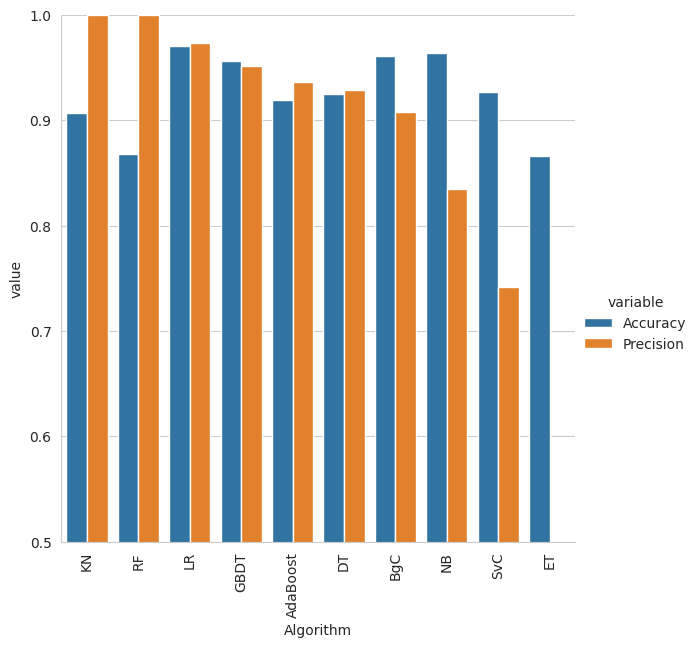

In [65]:
performance_df1 = pd.melt(performance_df,id_vars = 'Algorithm')

sns.catplot(x = 'Algorithm',y = 'value',
            hue = 'variable', data=performance_df1, kind='bar',height=6)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [66]:
# model improve


In [67]:
# 1.change the max_features parameter of TfIdf

In [68]:
temp_df = pd.DataFrame({'Algorithm':algorithm_names,'Accuracy_max_ft_3000':accuracy_source,'Precision_max_ft_3000':precision_source}).sort_values('Precision_max_ft_3000',ascending=False)

In [69]:
# voting classifier
svc = SVC(kernel='sigmoid',gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50,max_depth=5)


from sklearn.ensemble import VotingClassifier


In [70]:
voting = VotingClassifier(estimators=[('svm',svc),('nb',mnb),('et',etc)],voting='soft')

In [71]:
voting.fit(X_train,y_train)


VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(max_depth=5,
                                                   n_estimators=50))],
                 voting='soft')

In [72]:
voting = VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid', probability=True)),
                              ('nb', MultinomialNB()),
                              ('et',
                               ExtraTreesClassifier(max_depth=5, n_estimators=50,random_state=2))],
                 voting='soft')

In [73]:
voting.fit(X_train, y_train)
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred, pos_label='spam'))

Accuracy 0.9545454545454546
Precision 0.9789473684210527


In [74]:
# appling stacking
estimators = [('svm',svc),('nb',mnb),('et',etc)]
final_estimator = AdaBoostClassifier()

In [75]:
from sklearn.ensemble import StackingClassifier

In [76]:
clf = StackingClassifier(estimators=estimators,final_estimator=final_estimator)

In [79]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred, pos_label='spam'))

Accuracy 0.9796905222437138
Precision 0.968


In [80]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))